In [31]:
# 필요한 라이브러리 임포트
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd

mercari_df= pd.read_csv('mercari_train.tsv', sep='\t')
print(mercari_df.shape)
mercari_df.head(3)

(229990, 8)


,544201,Journey over the knee black suede boot,1,Women/Shoes/Boots,Unnamed: 4,41.0,0,Brand new never worn. Ordered 2 by accident Paid 80
0,544202,FREESHIP,1.0,Handmade/Books and Zines/Journal,NaN,8.0,1.0,Handmade notebook from Guatemala. Comes with a bookmark.
1,544203,Yeezy 750 Boost,3.0,Men/Shoes/Fashion Sneakers,Adidas,226.0,0.0,Yeezy 750 boost for sale. They have been worn twice but still in very good condition. Comes with original box and receipt.
2,544204,Giant Thai Pomelo Fruit Squishy,1.0,Vintage & Collectibles/Antique/Collectibles,NaN,33.0,1.0,This squishy is GIGANTIC ^_^ almost looks like a giant pear! Very soft and slow rising ToyBoxShop Thai Pomelo Fruit Manufacturers defects may apply! Size comparison to hand in picture 4 Kawaii - S...


In [32]:
# Mercari Price Suggestion 데이터셋의 표준 컬럼명 리스트 정의
mercari_columns = ['train_id', 'name', 'item_condition_id', 'category_name',
                   'brand_name', 'price', 'shipping', 'item_description']

# header=None으로 첫 번째 줄부터 데이터임을 알리고, names 파라미터로 컬럼명을 직접 덮어씌움
mercari_df = pd.read_csv('mercari_train.tsv', sep='\t', header=None, names=mercari_columns)

print(mercari_df.columns)

Index(['train_id', 'name', 'item_condition_id', 'category_name', 'brand_name',
       'price', 'shipping', 'item_description'],
      dtype='object')


In [33]:
print(mercari_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229991 entries, 0 to 229990
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   train_id           229991 non-null  int64  
 1   name               229990 non-null  object 
 2   item_condition_id  229990 non-null  float64
 3   category_name      228997 non-null  object 
 4   brand_name         131981 non-null  object 
 5   price              229990 non-null  float64
 6   shipping           229990 non-null  float64
 7   item_description   229990 non-null  object 
dtypes: float64(3), int64(1), object(4)
memory usage: 14.0+ MB
None


In [34]:
# 데이터프레임의 모든 컬럼명을 리스트 형태로 출력하여 확인
print(mercari_df.columns)

Index(['train_id', 'name', 'item_condition_id', 'category_name', 'brand_name',
       'price', 'shipping', 'item_description'],
      dtype='object')


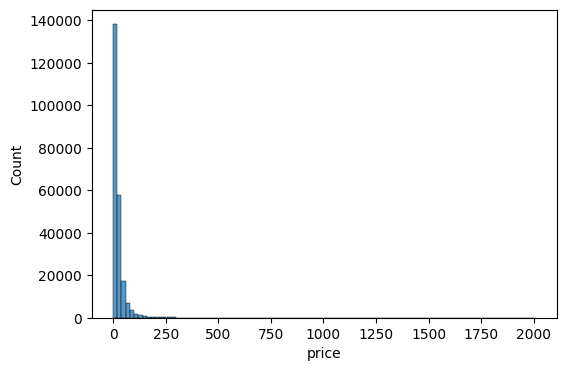

In [35]:
# 시각화를 위한 라이브러리 임포트
import matplotlib.pyplot as plt
import seaborn as sns

# 타겟 변수인 'price' 데이터 추출
y_train_df = mercari_df['price']

# 가격 데이터의 분포를 히스토그램으로 시각화하여 확인
plt.figure(figsize=(6,4))
sns.histplot(y_train_df, bins=100)
plt.show()

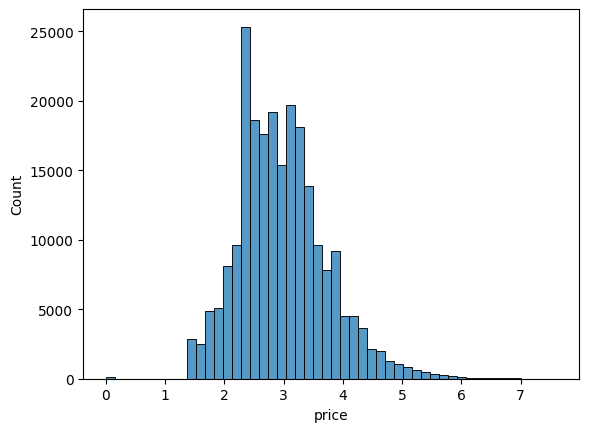

In [36]:
import numpy as np

# 로그 변환(log1p)을 적용하여 오른쪽으로 치우친 가격 데이터 분포를 정규분포에 가깝게 개선
y_train_df = np.log1p(y_train_df)

# 로그 변환된 데이터의 분포를 히스토그램으로 다시 시각화하여 확인 (구간 50개)
sns.histplot(y_train_df, bins=50)
plt.show()

In [37]:
# 원본 데이터프레임의 'price' 컬럼에 로그 변환을 적용하여 정규화된 값으로 덮어쓰기
mercari_df['price'] = np.log1p(mercari_df['price'])
mercari_df['price'].head(3)

,price
0,3.737670
1,2.197225
2,5.424950


In [38]:
# 'item_description' 컬럼의 값이 'No description yet'인 데이터만 찾는 불리언 조건 생성
boolean_cond= mercari_df['item_description']=='No description yet'

# 조건에 맞는(실질적으로 결측치에 해당하는) 텍스트 데이터의 총 개수 확인
mercari_df[boolean_cond]['item_description'].count()

np.int64(12908)

In [39]:
# 카테고리 데이터를 '/' 기준으로 대, 중, 소분류로 분할하는 함수 정의
def split_cat(category_name):
    try:
        return category_name.split('/')
    except:
        return ['Other_Null', 'Other_Null', 'Other_Null']

# lambda와 zip을 활용해 기존 카테고리 컬럼을 3개의 새로운 분류 컬럼으로 분리하여 생성
mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = \
    zip(*mercari_df['category_name'].apply(lambda x : split_cat(x)))

# 대분류의 종류와 데이터 건수 출력
print('대분류 유형 :\n', mercari_df['cat_dae'].value_counts())

# 중분류와 소분류는 종류가 많으므로 고유한 값의 개수만 출력
print('중분류 개수 :', mercari_df['cat_jung'].nunique())
print('소분류 개수 :', mercari_df['cat_so'].nunique())

대분류 유형 :
 cat_dae
Women                     102837
Beauty                     32272
Kids                       26694
Electronics                19162
Men                        14536
Home                       10536
Vintage & Collectibles      7166
Other                       7076
Handmade                    4848
Sports & Outdoors           3870
Other_Null                   994
Name: count, dtype: int64
중분류 개수 : 114
소분류 개수 : 767


In [40]:
# 텍스트 피처의 결측치를 일괄적으로 'Other_Null' 문자열로 대체
mercari_df['brand_name'] = mercari_df['brand_name'].fillna(value='Other_Null')
mercari_df['category_name'] = mercari_df['category_name'].fillna(value='Other_Null')
mercari_df['item_description'] = mercari_df['item_description'].fillna(value='Other_Null')

# 각 컬럼별 결측치 개수를 다시 확인하여 모두 0인지 검증
mercari_df.isnull().sum()

,0
train_id,0
name,1
item_condition_id,1
category_name,0
brand_name,0
price,1
shipping,1
item_description,0
cat_dae,0
cat_jung,0


In [41]:
# 브랜드명의 고유한 값 개수를 확인하여 범주형 데이터의 분포 종류 파악
print('brand name 의 유형 건수 :', mercari_df['brand_name'].nunique())

# 가장 빈번하게 등장하는 상위 5개 브랜드명과 그 빈도수 출력
print('brand name sample 5건 : \n', mercari_df['brand_name'].value_counts()[:5])

brand name 의 유형 건수 : 2717
brand name sample 5건 : 
 brand_name
Other_Null           98010
Nike                  8372
PINK                  8290
Victoria's Secret     7382
LuLaRoe               4775
Name: count, dtype: int64


In [42]:
# 상품명의 고유한 값 개수를 확인하여 텍스트 피처로서의 특성 파악
print('name 의 종류 개수 :', mercari_df['name'].nunique())

# 실제 상품명 텍스트 데이터의 형태를 7건만 추출하여 미리보기
print('name sample 7건: \n', mercari_df['name'][:7])

name 의 종류 개수 : 210110
name sample 7건: 
 0      Journey over the knee black suede boot
1                                    FREESHIP
2                             Yeezy 750 Boost
3             Giant Thai Pomelo Fruit Squishy
4                                  Lisa shirt
5                     RESERVED FOR Gapeach042
6    Gold mushu & cricket exclusive funko pop
Name: name, dtype: object


In [43]:
# 긴 텍스트 데이터가 생략되지 않고 출력되도록 pandas의 최대 컬럼 너비 설정 변경
pd.set_option('max_colwidth', 200)

# 텍스트 피처 벡터화(TF-IDF 등) 파라미터 설정을 참고하기 위해 평균 문자열 길이 계산
print('item_description 평균 문자열 크기:', mercari_df['item_description'].str.len().mean())

# 실제 상품 설명 텍스트 데이터의 형태를 2건만 추출하여 미리보기
mercari_df['item_description'][:2]

item_description 평균 문자열 크기: 146.09941258570987


,item_description
0,Brand new never worn. Ordered 2 by accident Paid 80
1,Handmade notebook from Guatemala. Comes with a bookmark.


In [45]:
# 상품명('name') 컬럼의 결측치를 'Other_Null' 문자열로 대체하여 벡터화 에러 방지
mercari_df['name'] = mercari_df['name'].fillna(value='Other_Null')

# 짧은 텍스트인 상품명('name')은 단어의 출현 빈도 기반인 CountVectorizer를 적용하여 벡터화
cnt_vec = CountVectorizer()
X_name = cnt_vec.fit_transform(mercari_df.name)

# 긴 텍스트인 상품 설명('item_description')은 단어의 중요도를 반영하는 TF-IDF 기반으로 벡터화
tfidf_descp = TfidfVectorizer(max_features=50000, ngram_range=(1, 3), stop_words='english')
X_descp = tfidf_descp.fit_transform(mercari_df['item_description'])

# 벡터화 변환 후 생성된 희소 행렬의 크기 확인
print('name vectorization shape:', X_name.shape)
print('item_description vectorization shape:', X_descp.shape)

name vectorization shape: (229991, 38872)
item_description vectorization shape: (229991, 50000)


In [48]:
from sklearn.preprocessing import LabelBinarizer

# 범주형 피처를 원-핫 인코딩 변환 (메모리 효율을 위해 희소 행렬 형태로 출력)
lb_brand_name = LabelBinarizer(sparse_output=True)
X_brand = lb_brand_name.fit_transform(mercari_df['brand_name'])

mercari_df['item_condition_id'] = mercari_df['item_condition_id'].fillna(0)
mercari_df['shipping'] = mercari_df['shipping'].fillna(0)

lb_item_cond_id = LabelBinarizer(sparse_output=True)
X_item_cond_id = lb_item_cond_id.fit_transform(mercari_df['item_condition_id'])

lb_shipping = LabelBinarizer(sparse_output=True)
X_shipping = lb_shipping.fit_transform(mercari_df['shipping'])

# 분리된 카테고리(대, 중, 소분류) 피처들도 동일하게 희소 행렬 원-핫 인코딩 적용
lb_cat_dae = LabelBinarizer(sparse_output=True)
X_cat_dae = lb_cat_dae.fit_transform(mercari_df['cat_dae'])

lb_cat_jung = LabelBinarizer(sparse_output=True)
X_cat_jung = lb_cat_jung.fit_transform(mercari_df['cat_jung'])

lb_cat_so = LabelBinarizer(sparse_output=True)
X_cat_so = lb_cat_so.fit_transform(mercari_df['cat_so'])

# 정상적으로 변환되었는지 데이터 타입(희소 행렬 객체 여부)과 형태(shape) 확인
print(type(X_brand), type(X_item_cond_id), type(X_shipping))
print('X_brand shape:{0}, X_item_cond_id shape:{1}'.format(X_brand.shape, X_item_cond_id.shape))
print('X_shipping shape:{0}, X_cat_dae shape:{1}'.format(X_shipping.shape, X_cat_dae.shape))
print('X_cat_jung shape:{0}, X_cat_so shape:{1}'.format(X_cat_jung.shape, X_cat_so.shape))

<class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'>
X_brand shape:(229991, 2717), X_item_cond_id shape:(229991, 6)
X_shipping shape:(229991, 1), X_cat_dae shape:(229991, 11)
X_cat_jung shape:(229991, 114), X_cat_so shape:(229991, 767)


In [49]:
from scipy.sparse import hstack
import gc

# 결합할 모든 희소 행렬 피처들을 튜플 형태로 묶기
sparse_matrix_list = (X_name, X_descp, X_brand, X_item_cond_id, \
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

# hstack을 사용하여 텍스트 벡터화 및 원-핫 인코딩된 희소 행렬들을 가로 방향으로 결합하여 최종 피처 세트 생성
X_features_sparse= hstack(sparse_matrix_list).tocsr()
print(type(X_features_sparse), X_features_sparse.shape)

# 대용량 희소 행렬이 메모리를 많이 차지하므로, 메모리 확보를 위해 객체 삭제 및 가비지 컬렉션 수행
del X_features_sparse
gc.collect()

<class 'scipy.sparse._csr.csr_matrix'> (229991, 92488)


612

In [50]:
# 실제 값과 예측 값의 차이를 평가하기 위한 RMSLE 계산 함수 정의
def rmsle(y, y_pred):
    # 계산 과정에서 발생할 수 있는 underflow나 overflow를 방지하기 위해 log 대신 log1p 적용
    return np.sqrt(np.mean(np.power(np.log1p(y) - np.log1p(y_pred), 2)))

# 학습 시 로그 변환했던 가격 데이터를 원래 스케일로 되돌려 최종 오차를 평가하는 함수
def evaluate_org_price(y_test, preds):
    # 타겟 데이터(price)가 log1p로 변환되어 있으므로, 지수 변환인 expm1을 사용해 원래 가격으로 복원
    preds_exmpm = np.expm1(preds)
    y_test_exmpm = np.expm1(y_test)

    # 원상 복구된 가격 데이터를 바탕으로 실제 RMSLE 값 계산
    rmsle_result = rmsle(y_test_exmpm, preds_exmpm)
    return rmsle_result

In [52]:
import gc
from scipy.sparse import hstack

def model_train_predict(model, matrix_list):
    # 여러 피처가 담긴 희소 행렬 리스트를 가로로 결합하여 최종 피처 데이터 세트 생성
    X = hstack(matrix_list).tocsr()

    # 전체 데이터를 학습용 데이터와 검증용 데이터 세트로 8:2 분리
    X_train, X_test, y_train, y_test = train_test_split(X, mercari_df['price'],
                                                        test_size=0.2, random_state=156)

    # 전달받은 머신러닝 모델을 이용해 학습 및 예측 수행
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    # 대용량 희소 행렬이 메모리를 많이 차지하므로 불필요해진 변수 즉시 삭제
    del X, X_train, X_test, y_train
    gc.collect()

    return preds, y_test

In [55]:
# 선형 회귀 모델인 Ridge 객체 생성 (희소 행렬 연산에 최적화된 lsqr 솔버 사용)
linear_model = Ridge(solver = "lsqr", fit_intercept=False)

# 상품 설명(item_description) 피처를 제외한 데이터 세트 구성
sparse_matrix_list = (X_name, X_brand, X_item_cond_id, \
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

# 텍스트 피처 제외 시 모델 학습/예측 및 오차(RMSLE) 평가 지표 출력
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description을 제외했을 때 rmsle 값:', evaluate_org_price(y_test, linear_preds))

# 상품 설명(X_descp) 피처를 포함하여 전체 데이터 세트 다시 구성
sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id, \
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

# 텍스트 피처 포함 시 모델 학습/예측 및 오차(RMSLE) 평가 지표 출력 (텍스트 데이터의 예측 기여도 확인)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description을 포함한 rmsle 값:', evaluate_org_price(y_test, linear_preds))

Item Description을 제외했을 때 rmsle 값: 0.5215397758473034
Item Description을 포함한 rmsle 값: 0.5034553182876718


In [56]:
from lightgbm import LGBMRegressor

# 상품 설명(item_description) 피처를 포함한 전체 데이터 세트 구성
sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id,
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

# 트리 기반 앙상블 알고리즘인 LightGBM 회귀 모델 객체 생성
# n_estimators(트리 개수), learning_rate(학습률), num_leaves(리프 노드 수) 등 주요 하이퍼파라미터 설정
lgbm_model = LGBMRegressor(n_estimators=200, learning_rate=0.5, num_leaves=125, random_state=156)

# LightGBM 모델을 이용한 학습 및 예측 수행 후, 원래 가격 스케일로 복원하여 오차(RMSLE) 출력
lgbm_preds, y_test = model_train_predict(model = lgbm_model, matrix_list=sparse_matrix_list)
print('LightGBM rmsle 값:', evaluate_org_price(y_test, lgbm_preds))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 128.469335 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 861611
[LightGBM] [Info] Number of data points in the train set: 183992, number of used features: 32853
[LightGBM] [Info] Start training from score 2.977395


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM rmsle 값: 0.5106107454618412


In [57]:
# 트리 모델(LightGBM)과 선형 회귀 모델(Ridge)의 예측값을 45:55 비율로 가중 평균(Blending)하여 앙상블
# 서로 다른 특성을 가진 모델을 결합하여 단일 모델의 약점을 보완하고 예측 성능(일반화)을 극대화함
preds = lgbm_preds * 0.45 + linear_preds * 0.55

# 두 모델을 결합한 최종 앙상블 예측 결과의 오차(RMSLE)를 평가하여 단일 모델 대비 성능 향상 확인
print('LightGBM과 Ridge를 ensemble한 최종 rmsle 값:', evaluate_org_price(y_test, preds))

LightGBM과 Ridge를 ensemble한 최종 rmsle 값: 0.4838314655249773
